# The basic shepherding experiment, end to end

This notebook runs one repetition of the repo's basic point-to-point herding
experiment — the single-rep equivalent of `experiments/test.py`'s `run_target`
— from initializing a flock all the way to watching the rendered video of the
run:

1. **Configure & seed** — read the frozen experiment config from `basic/__init__.py`.
2. **Flocking warm-up** — let the sheep self-organize for `TICK` ticks with no shepherds.
3. **Herding** — release the shepherds and simulate until every sheep is inside
   the target circle (or the tick budget runs out), recording a frame every
   `DRAW_INTERVAL` ticks.
4. **Render** — stream the recorded frames through ffmpeg into an mp4
   (`basic.drawing.video.write_video`, PyGame's offscreen-`Surface` renderer).
5. **Play** — embed the video right here in the notebook.

**How to run:** use the project virtualenv as the kernel (`.venv` at the repo
root has `ipykernel` installed — point Jupyter/VS Code at `.venv/bin/python`,
or register it with `.venv/bin/python -m ipykernel install --user --name
shepherding`), then *Run All*. A full run takes on the order of a minute, most
of it numba JIT compilation and video encoding.

In [1]:
import os

# Cap the numeric thread pools BEFORE numpy/numba first load them. The
# simulation's BLAS calls are on tiny per-agent vectors (no parallel win), and
# an uncapped OpenBLAS spawns one thread per core — in containerized or
# thread-budgeted environments that can exhaust the PID budget the ffmpeg
# encoder needs later in this notebook. setdefault keeps any explicit
# user-level configuration in charge.
for var in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(var, "1")

import random
import sys
from pathlib import Path
from timeit import default_timer as timer

import numba as nb
import numpy as np

# Resolve the repo root (the directory holding pyproject.toml) so paths work no
# matter where Jupyter was launched from. `import basic` already works when the
# kernel is the project venv (editable install); the sys.path insert covers any
# other kernel.
REPO_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()),
    None,
)
assert REPO_ROOT is not None, "run this notebook from inside the repository"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from basic import (
    DRAW_FPS,
    DRAW_INTERVAL,
    FENCE,
    MODE,
    MORPHOLOGY,
    TARGET,
    TARGET_SIZE,
    TARGET_X,
    TARGET_Y,
)
# Migrated off basic.drawing.draw's Matplotlib renderer onto the PyGame one:
# save_frame_png (single-frame PNG snapshots) and write_video/ffmpeg_exe
# (streamed mp4 rendering) are display-free by construction, so they work in
# this no-display container exactly as the old matplotlib-Agg path did.
# `shutil` and `matplotlib.pyplot` are no longer imported here — ffmpeg_exe()
# below does its own PATH + imageio-ffmpeg lookup (replacing this notebook's
# old shutil-based shim), and snapshot() below renders through save_frame_png
# instead of pyplot.
from basic.drawing.pygame_draw import save_frame_png
from basic.drawing.video import write_video, ffmpeg_exe
from basic.herding.initiation import initiate, initiate_shepherds
from basic.herding.interaction import evolve

# This notebook follows the point-to-point experiment (test.py's run_target).
assert not MORPHOLOGY, "set MORPHOLOGY = False in basic/__init__.py and restart"

print(f"MODE = {MODE} | FENCE = {FENCE} | target = {TARGET}")

MODE = 0 | FENCE = False | target = (400, 400, 125)


## Experiment configuration

All experiment-defining constants (`MODE`, `MORPHOLOGY`, `FENCE`, the target)
live in `basic/__init__.py` and are **frozen into the numba-compiled kernels at
import time**. To run a different shepherd strategy, edit `MODE` there and
**restart the kernel** — re-running cells is not enough.

| MODE | Shepherd's flock-center estimate |
|---|---|
| 0 | Center of mass of all moving sheep (full global knowledge) |
| 1 | Vision projection: bearings + angular widths only (experimental, currently broken) |
| 2 | Mean of the convex-hull vertices of the moving sheep |
| 3 | Mean of the hull vertices *visible to the shepherd* |
| 4 | Per-subflock visible hulls (nearest subflock first) |

This notebook was authored and tested with `MODE = 0`, the original
Strömbom-style center-of-mass strategy (see the README's *Shepherd strategies*
section for the full descriptions).

### ffmpeg

`write_video` pipes raw RGBA frames straight into an `ffmpeg` binary found by
`ffmpeg_exe()` (`basic.drawing.video`): it checks `PATH` first, then falls
back directly to the binary bundled inside the `imageio-ffmpeg` wheel. That
fallback resolves the wheel's versioned filename itself, so — unlike the old
`draw_dynamic` path, which only ever checked `PATH` via `shutil.which` — this
notebook no longer needs to build its own symlink shim exposing that binary
under a plain `ffmpeg` name; the cell below just confirms one was found.

In [2]:
# Obsolete as a *shim*: this cell used to build notebooks/.ffmpeg-shim, a
# symlink exposing imageio-ffmpeg's versioned-filename binary under a plain
# "ffmpeg" name on PATH, because the old draw_dynamic only ever looked ffmpeg
# up via shutil.which. basic.drawing.video.ffmpeg_exe() now does that PATH
# lookup itself and falls back to imageio_ffmpeg.get_ffmpeg_exe() directly,
# so no shim/symlink is needed — this cell just confirms one was found.
FFMPEG = ffmpeg_exe()
assert FFMPEG is not None, "no ffmpeg on PATH, and imageio-ffmpeg is not installed"
print("ffmpeg:", FFMPEG)

ffmpeg: /workspace/Shepherding-Behavior/.venv/lib/python3.12/site-packages/imageio_ffmpeg/binaries/ffmpeg-linux-x86_64-v7.0.2


## Repetition parameters

`experiments/test.py` sweeps 64 seeded repetitions of a 300-sheep, 3-shepherd
flock in parallel. Here we run **one** repetition, sized down to
50 sheep so the whole notebook finishes in about a minute. With the
full-size `N_SHEEP = 300` a single MODE-0 rep usually *times out* at the
200 000-tick budget (and takes a few minutes of wall clock), so the demo uses a
flock the shepherds can reliably deliver.

In [3]:
N_SHEEP = 50  # flock size (test.py: 300)
N_SHEPHERD = 3  # shepherd count (test.py: 3)
SPACE_X = SPACE_Y = 150  # initial flock spawn box
SEED = 0  # the repetition number doubles as the RNG seed

TICK = 1000  # self-organized flocking warm-up ticks (no shepherds yet)
ITERATIONS = 100000  # herding tick budget before a timeout (test.py: 200000)

# Viewing window, as in experiments/test.py.
BOUNDARY_X = TARGET_X + TARGET_SIZE + 300
BOUNDARY_Y = TARGET_Y + TARGET_SIZE + 300

# L3: average flock radius per shepherd — the shepherd-shepherd avoidance radius.
L3 = np.sqrt(N_SHEEP / N_SHEPHERD) * 5

### Seeding

The simulation kernels are numba-compiled, and numba's `np.random` state is
separate from the interpreter's — seeding must happen *inside* nopython code to
land in the RNG the kernels actually draw from (the same trick as `test.py`'s
`seed_run`).

In [4]:
@nb.jit(nopython=True)
def seed_run(seed: int):
    random.seed(seed)
    np.random.seed(seed)


seed_run(SEED)

## Stage 1 — initialize the flock and let it self-organize

`initiate` builds the sheep state matrix (one row per sheep: position, heading,
force-model constants, and bookkeeping columns). The flock first evolves for
`TICK` ticks against an **empty** shepherd array, so it settles into a
cohesive, self-organized group before herding starts.

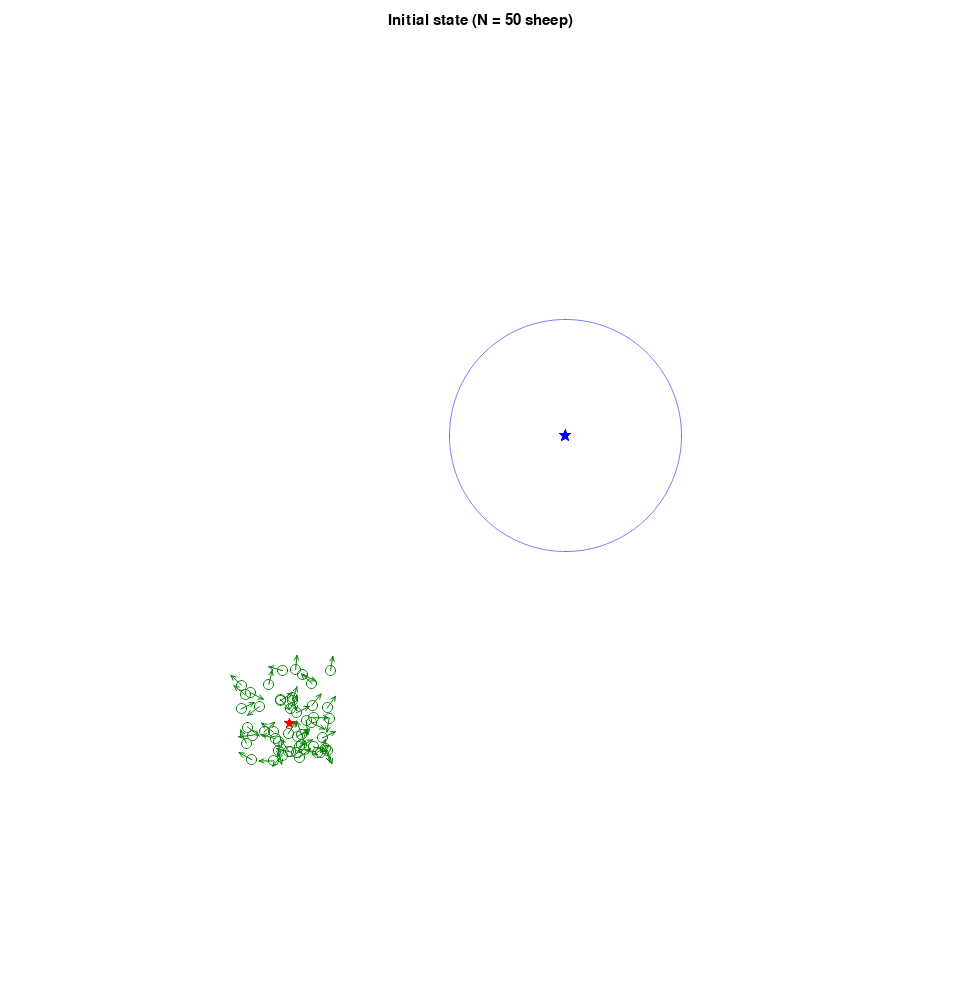

In [5]:
from IPython.display import Image, display

agents = initiate(N_SHEEP, N_SHEPHERD, SPACE_X, SPACE_Y, TARGET_SIZE)
shepherds = initiate_shepherds(0, N_SHEPHERD, L3)  # zero shepherds during warm-up

# Snapshots render offscreen through the PyGame renderer and are saved as
# PNGs under notebooks/media/ (gitignored, created here since it's also
# reused by the Stage-3 video render below) before being displayed inline.
media_dir = REPO_ROOT / "notebooks" / "media"
media_dir.mkdir(parents=True, exist_ok=True)
snapshot_count = 0  # gives each snapshot() call below a distinct PNG filename


def snapshot(agents, shepherds, title):
    """Renders one frame through the PyGame renderer and displays it inline.

    Writes a PNG to `media_dir` and displays it via `IPython.display.Image`.
    Unlike the old Matplotlib-based version of this helper, no zero-shepherd
    workaround is needed here: `save_frame_png` (and the `render_frame` it
    wraps) handles an empty `shepherds` array (M = 0) natively. The old
    special case existed only because draw_single's Matplotlib drive/collect
    color cycler raised on an empty shepherd array — a Matplotlib-specific
    limitation the PyGame renderer doesn't share.
    """
    global snapshot_count
    snapshot_count += 1
    path = media_dir / f"snapshot_{snapshot_count:02d}.png"
    save_frame_png(
        str(path), agents, shepherds, (BOUNDARY_X, BOUNDARY_Y), TARGET, MODE, hud=title
    )
    # display() (rather than relying on this being the cell's trailing
    # expression) mirrors the old plt.show() side effect: the Stage-2 results
    # cell below calls snapshot() mid-cell, not as its last statement, so an
    # auto-displayed return value alone would not render there.
    display(Image(filename=str(path)))


snapshot(agents, shepherds, f"Initial state (N = {N_SHEEP} sheep)")

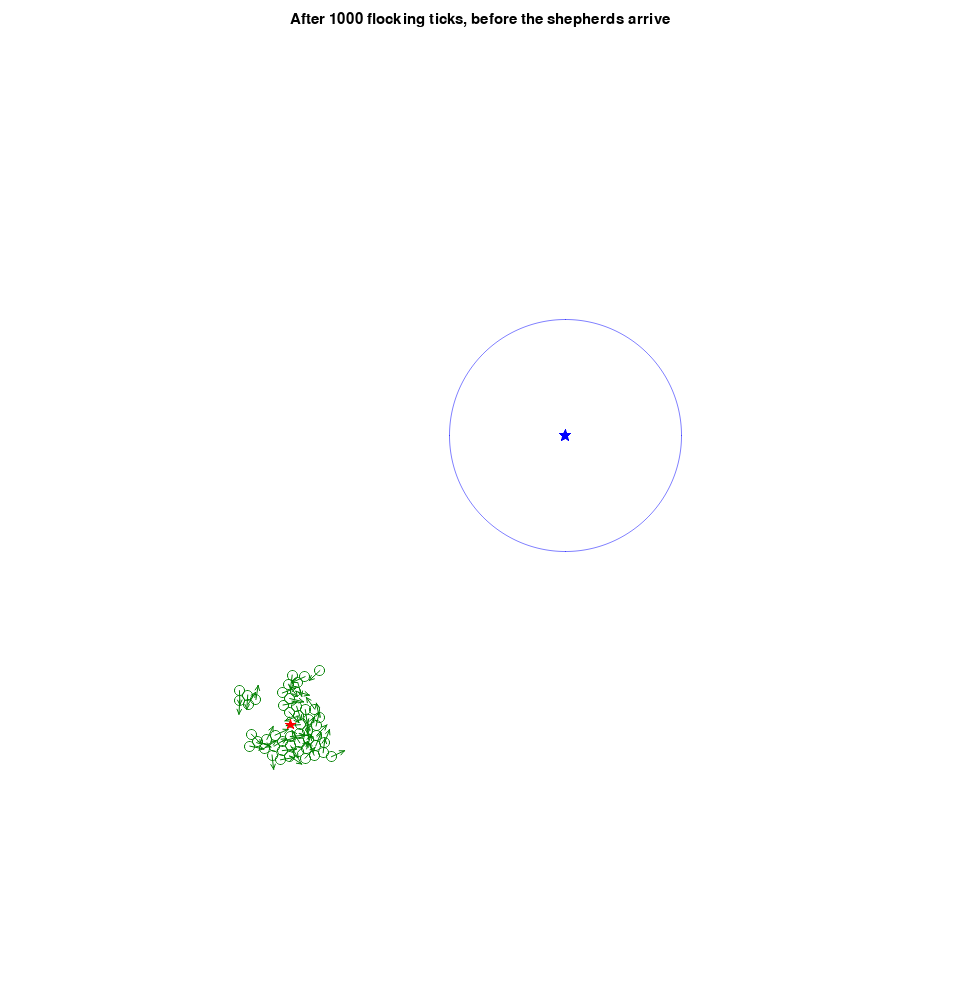

In [6]:
for tick in range(TICK):
    agents, shepherds, max_agents_indices = evolve(agents, shepherds, *TARGET)

snapshot(agents, shepherds, f"After {TICK} flocking ticks, before the shepherds arrive")

## Stage 2 — release the shepherds and herd

The real shepherds spawn near the origin and alternate between *driving* the
flock toward the target and *collecting* stragglers. The run terminates when
**every** sheep is in the *staying* state (column 21, set once a sheep settles
inside the target circle) — or when the tick budget runs out.

Frames for the video are recorded exactly as `experiments/test.py` does in
`DRAW` mode: every `DRAW_INTERVAL`-th tick, plus the true final tick, so the
video always ends on the actual final state.

In [7]:
shepherds = initiate_shepherds(N_SHEPHERD, N_SHEEP, L3)

n_slots = ITERATIONS // DRAW_INTERVAL + 2
data_agents = np.zeros((agents.shape[0], agents.shape[1], n_slots), float)
data_shepherds = np.zeros((shepherds.shape[0], shepherds.shape[1], n_slots), float)
frame_ticks = np.zeros(n_slots, int)  # real sim tick behind each recorded frame
frame = 0

final_tick: int = ITERATIONS
success: bool = False
start = timer()
for tick in range(ITERATIONS):
    agents, shepherds, max_agents_indices = evolve(agents, shepherds, *TARGET)
    done = bool(np.all(agents[:, 21] == 1))
    if tick % DRAW_INTERVAL == 0 or done or tick == ITERATIONS - 1:
        data_agents[:, :, frame] = agents
        data_shepherds[:, :, frame] = shepherds
        frame_ticks[frame] = tick
        frame += 1
    if tick % 5000 == 0:
        print(f"tick {tick}: {int((agents[:, 21] == 1).sum())}/{N_SHEEP} staying")
    if done:
        final_tick = tick
        success = True
        break
elapsed = timer() - start

print(
    f"{'SUCCESS' if success else 'TIMEOUT'}: final_tick={final_tick} "
    f"({(final_tick + 1) / elapsed:.0f} ticks/s, {frame} frames recorded)"
)

tick 0: 0/50 staying
tick 5000: 0/50 staying
tick 10000: 0/50 staying


tick 15000: 0/50 staying
tick 20000: 0/50 staying
tick 25000: 0/50 staying


tick 30000: 0/50 staying
tick 35000: 0/50 staying
tick 40000: 0/50 staying


tick 45000: 0/50 staying
tick 50000: 5/50 staying
tick 55000: 44/50 staying
SUCCESS: final_tick=55817 (57783 ticks/s, 560 frames recorded)


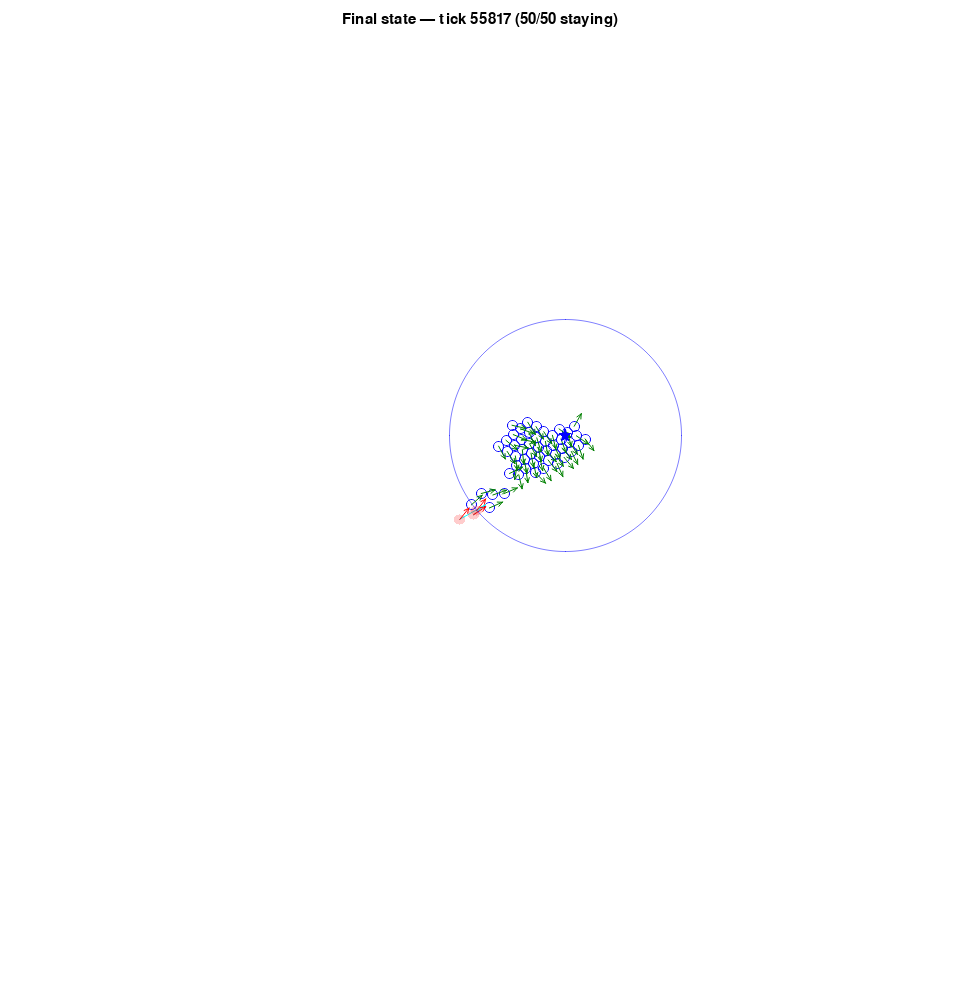

{'N_SHEEP': 50,
 'N_SHEPHERD': 3,
 'MODE': 0,
 'Repetition': 0,
 'final_tick': 55817,
 'Success': True,
 'Experiment_type': 'target'}

In [8]:
results = {
    "N_SHEEP": N_SHEEP,
    "N_SHEPHERD": N_SHEPHERD,
    "MODE": MODE,
    "Repetition": SEED,
    "final_tick": final_tick,
    "Success": success,
    "Experiment_type": "target",
}
snapshot(
    agents,
    shepherds,
    f"Final state — tick {final_tick} "
    f"({int((agents[:, 21] == 1).sum())}/{N_SHEEP} staying)",
)
results

## Stage 3 — render the run to video

`write_video` re-renders every recorded frame into a single reused, offscreen
PyGame `Surface` and pipes the raw RGBA pixels straight into an ffmpeg process
that encodes H.264/yuv420p as the frames arrive — no intermediate PNGs or
other per-frame files ever touch disk. At `DRAW_FPS = 10` playback and one
frame per `DRAW_INTERVAL = 100` ticks, one video second ≈ 1 000 simulation
ticks.

(`experiments/test.py` names its videos `MODE_0|Rep_0|final_… .mp4`; the `|`
characters make awkward URLs for browser playback, so this notebook names its
file without them.)

In [9]:
# media_dir was already created above (Stage 1, next to the snapshot() helper).
video_path = media_dir / f"basic_experiment_MODE_{MODE}_rep_{SEED}.mp4"

start = timer()
write_video(
    (frame_ticks[:frame], L3, MODE),
    (data_agents[:, :, :frame], data_shepherds[:, :, :frame]),
    (BOUNDARY_X, BOUNDARY_Y),
    (TARGET_X, TARGET_Y, TARGET_SIZE),
    str(video_path),
)
print(
    f"rendered {frame} frames -> {video_path.relative_to(REPO_ROOT)} "
    f"({video_path.stat().st_size / 2**20:.1f} MB) in {timer() - start:.0f}s"
)

rendered 560 frames -> notebooks/media/basic_experiment_MODE_0_rep_0.mp4 (1.4 MB) in 2s


## Play the sample video

Legend: sheep are the small green circles (blue-edged once they are *staying*
in the target); shepherds are the larger translucent dots — **red** while
driving, **blue** while collecting — each with a cyan line to its current
drive/collect point and a yellow dotted line to the straggler it is collecting;
the red star is the moving flock's center of mass; the blue star/circle is the
target.

In [10]:
from IPython.display import Video

# embed=True base64-inlines the mp4, so the saved .ipynb plays the video on its
# own (e.g. on GitHub/nbviewer) without needing the media/ file next to it.
Video(str(video_path), embed=True, width=720, html_attributes="controls loop")

## Where to go next

- **The full experiment:** `python experiments/test.py` runs 64 seeded
  repetitions in parallel (joblib) and writes a JSON result list plus a
  final-tick histogram to `results/fence/<MODE>/`; set `DRAW = True` there to
  render one video per repetition instead.
- **Analysis:** `data_analysis/parse.py` aggregates those results across modes.
- **Different strategies:** edit `MODE` in `basic/__init__.py`, restart the
  kernel, and rerun this notebook.